Random Forest, XGBoost

In [ ]:
!pip install xgboost lightgbm

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_PATH = '/content/drive/MyDrive/classification/train.csv'
df = pd.read_csv(DATA_PATH)
print(f'Số dòng : {df.shape[0]}')
print(f'Số cột  : {df.shape[1]}')
display(df.head())

Số dòng : 2190
Số cột  : 13


,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             2190 non-null   int64  
 1   day            2190 non-null   int64  
 2   pressure       2190 non-null   float64
 3   maxtemp        2190 non-null   float64
 4   temparature    2190 non-null   float64
 5   mintemp        2190 non-null   float64
 6   dewpoint       2190 non-null   float64
 7   humidity       2190 non-null   float64
 8   cloud          2190 non-null   float64
 9   sunshine       2190 non-null   float64
 10  winddirection  2190 non-null   float64
 11  windspeed      2190 non-null   float64
 12  rainfall       2190 non-null   int64  
dtypes: float64(10), int64(3)
memory usage: 222.6 KB
None


In [ ]:
df.describe()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
count,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000
mean,1094.500000,179.948402,1013.602146,26.365799,23.953059,22.170091,20.454566,82.036530,75.721918,3.744429,104.863151,21.804703,0.753425
std,632.342866,105.203592,5.655366,5.654330,5.222410,5.059120,5.288406,7.800654,18.026498,3.626327,80.002416,9.898659,0.431116
min,0.000000,1.000000,999.000000,10.400000,7.400000,4.000000,-0.300000,39.000000,2.000000,0.000000,10.000000,4.400000,0.000000
25%,547.250000,89.000000,1008.600000,21.300000,19.300000,17.700000,16.800000,77.000000,69.000000,0.400000,40.000000,14.125000,1.000000
50%,1094.500000,178.500000,1013.000000,27.800000,25.500000,23.850000,22.150000,82.000000,83.000000,2.400000,70.000000,20.500000,1.000000
75%,1641.750000,270.000000,1017.775000,31.200000,28.400000,26.400000,25.000000,88.000000,88.000000,6.800000,200.000000,27.900000,1.000000
max,2189.000000,365.000000,1034.600000,36.000000,31.500000,29.800000,26.700000,98.000000,100.000000,12.100000,300.000000,59.500000,1.000000


In [ ]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

id: 2190
day: 365
pressure: 236
maxtemp: 219
temparature: 198
mintemp: 199
dewpoint: 218
humidity: 49
cloud: 78
sunshine: 120
winddirection: 35
windspeed: 223
rainfall: 2


In [ ]:
missing = df.isnull().sum()
missing

,0
id,0
day,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
sunshine,0


In [ ]:
duplicate = df.duplicated().sum()
print("Số dòng trùng:", duplicate)
df[df.duplicated()]
df = df.drop_duplicates()
print("Số dòng trùng còn lại:", df.duplicated().sum())

Số dòng trùng: 0
Số dòng trùng còn lại: 0


In [ ]:
before = len(df)

df = df.drop_duplicates()

after = len(df)

print("Trước:", before)
print("Sau:", after)
print("Đã xóa:", before - after, "dòng")

Trước: 2190
Sau: 2190
Đã xóa: 0 dòng


In [ ]:
print(df['rainfall'].unique())

[1 0]


In [ ]:
target_percent = pd.DataFrame({
    'Count': df['rainfall'].value_counts(),
    'Pe'Percentagercentage (%)': round(df['rainfall'].value_counts(normalize=True) * 100, 2)
})
'Percentage
display(target_percent)

,Count,Percentage (%)
rainfall,,
1,1650,75.34
0,540,24.66


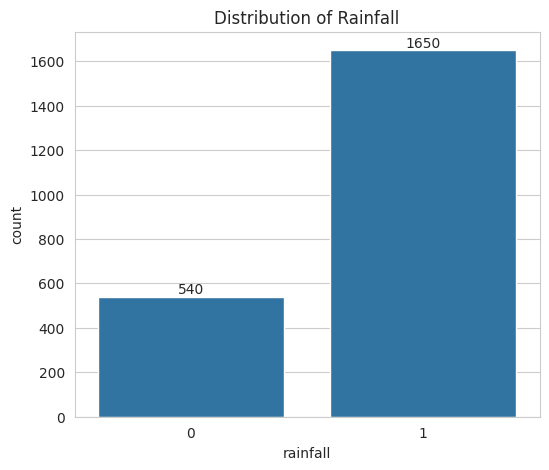

In [ ]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    x='r'rainfall'ainfall',
'rainfall'a=df
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Distribution of Rainfall")
plt.show()

Từ biểu đồ counplot trên, có thể thấy được biến rainfall có sự mất cân bằng mạnh.

In [ ]:

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

numeric_cols = numeric_cols.drop('rainfall')

skew_table = pd.DataFrame({
    "Feature": numeric_cols,
    "Skewness": [skew(df[col].dropna()) for col in numeric_cols]
})

skew_table = skew_table.sort_values(by="Skewness", key=abs, ascending=False)

display(skew_table)

,Feature,Skewness
8,cloud,-1.338357
6,dewpoint,-0.997206
11,windspeed,0.768863
10,winddirection,0.707578
5,mintemp,-0.648734
9,sunshine,0.639433
7,humidity,-0.561156
4,temparature,-0.557089
3,maxtemp,-0.490554
2,pressure,0.283868


Giá trị Skewness cho thấy biến cloud có độ lệch trái mạnh (Skewness = -1.338)

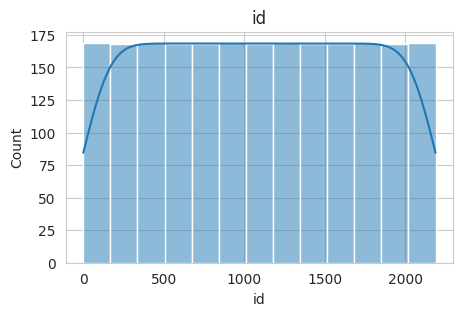

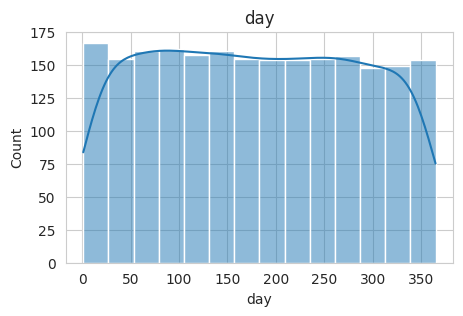

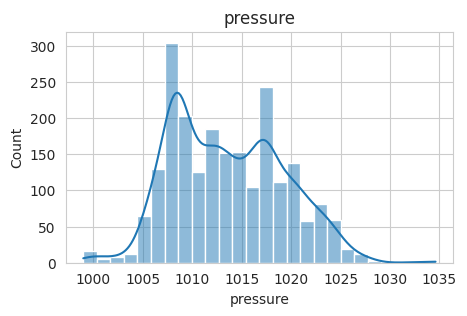

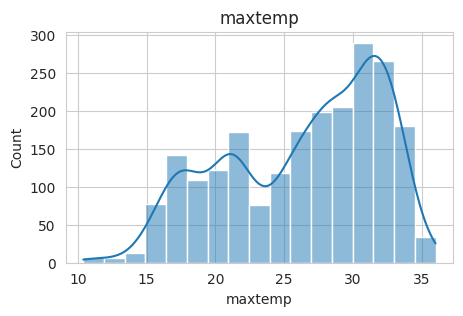

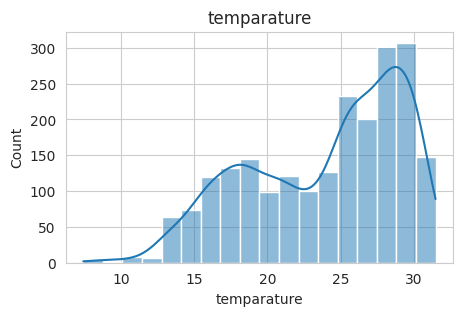

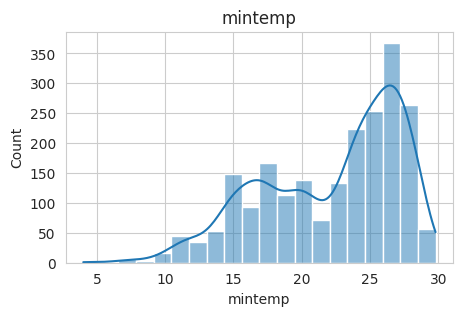

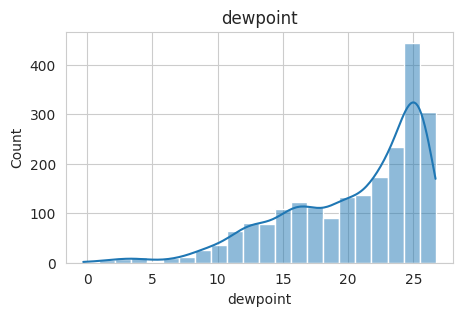

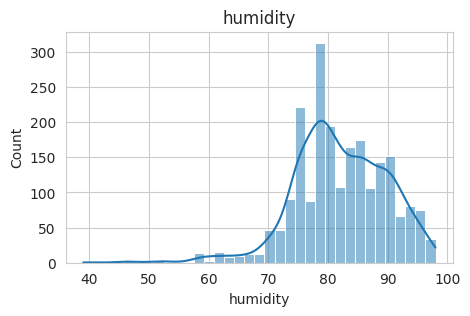

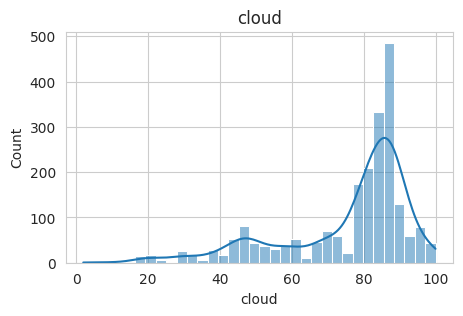

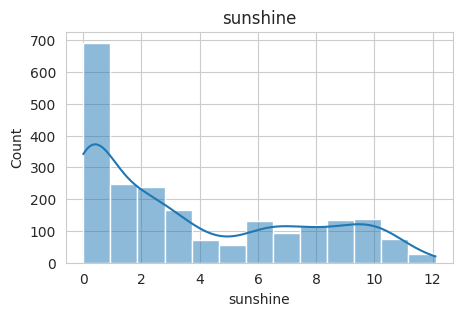

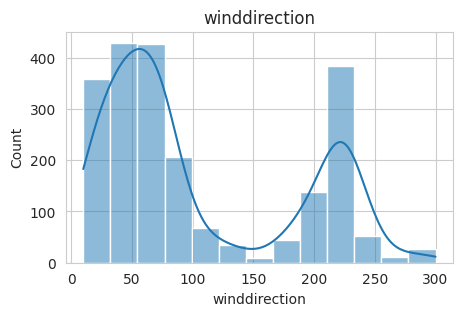

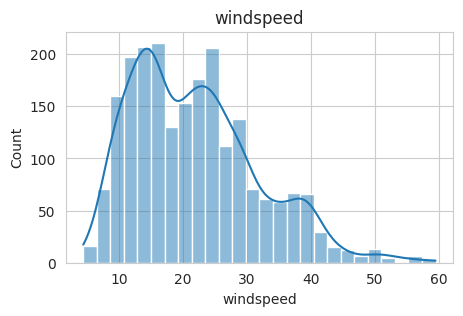

In [ ]:
for col in numeric_cols:

    plt.figure(figsize=(5,3))

    sns.histplot(df[col], kde=True)

    plt.title(col)

    plt.show()

In [ ]:
from sklearn.preprocessing import PowerTransformer
skew_cols = ['clou'cloud'd']
pt = PowerTransformer(method='yeo-johnson')
df[skew_cols] = pt.fit_transform(df[skew_cols])
for col in skew_cols:
    print(f"{col}: {skew(df[col]):.3f}")

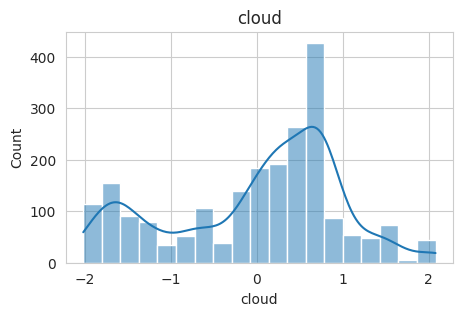

In [ ]:
plt.figure(figsize=(5,3))
sns.histplot(df['cloud'], kde=True)
plt.title('cloud')
plt.show()

dùng Power Transformation để cải thiện hiệu quả của Logistic Regression mà vẫn giữ nguyên thông tin của dữ liệu

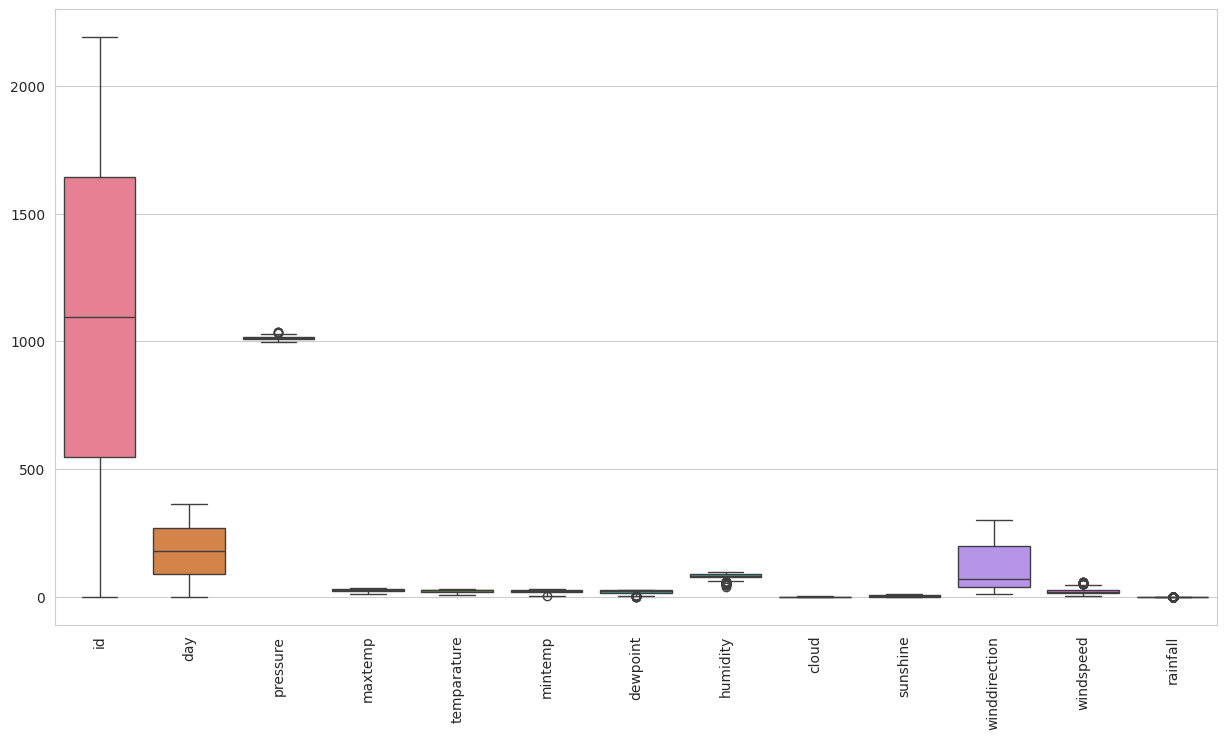

In [ ]:
numeric_cols = df.select_dtypes(
    include=['int64','float64']
).columns

plt.figure(figsize=(15,8))

sns.boxplot(
    data=df[numeric_cols]
)

plt.xticks(rotation=90)

plt.show()

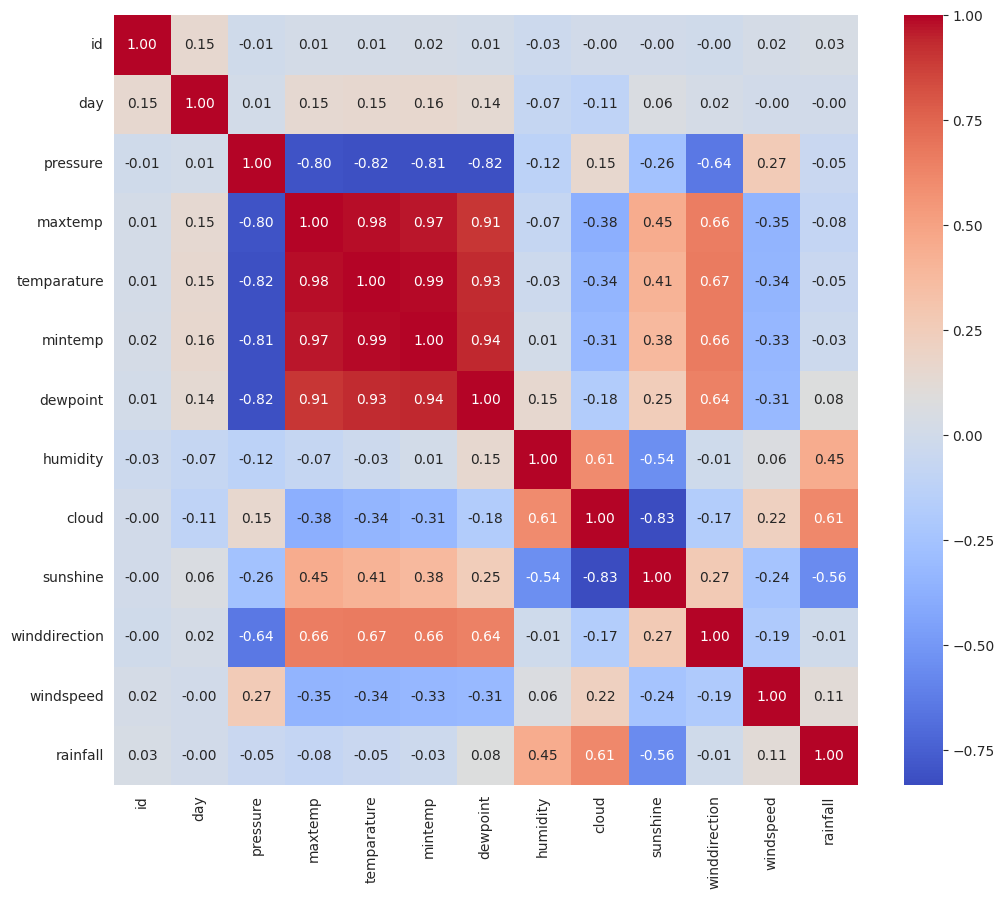

In [ ]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.show()

rainfall         1.000000
cloud            0.613239
humidity         0.454213
windspeed        0.111625
dewpoint         0.081965
id               0.033674
day             -0.000462
winddirection   -0.006939
mintemp         -0.026841
temparature     -0.049660
pressure        -0.049886
maxtemp         -0.079304
sunshine        -0.555287
Name: rainfall, dtype: float64


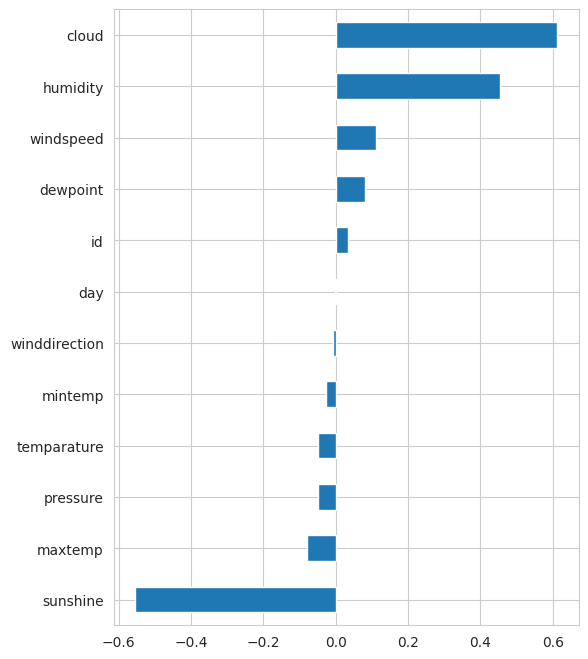

In [ ]:
corr = df.corr()['rainfall']\
        .sort_values(ascending=False)
print(corr)
plt.figure(figsize=(6,8))
corr.drop('rainfall').sort_values().plot.barh()
plt.show()

In [ ]:
df.drop(columns=['id', 'day'],inplace=True)
df.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,1017.4,21.2,20.6,19.9,19.4,87.0,0.742941,1.1,60.0,17.2,1
1,1019.5,16.2,16.9,15.8,15.4,95.0,1.044052,0.0,50.0,21.9,1
2,1024.1,19.4,16.1,14.6,9.3,75.0,-1.616209,8.3,70.0,18.1,1
3,1013.4,18.1,17.8,16.9,16.8,95.0,1.479240,0.0,60.0,35.6,1
4,1021.8,21.3,18.4,15.2,9.6,52.0,-1.666171,3.6,40.0,24.8,0


In [ ]:
X = df.drop(columns=['rainfall'], axis = 1)
y = df['rainfall']
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)

In [ ]:
numeric_cols = X_train.select_dtypes(include=np.number).columns

bounds = {}

for col in numeric_cols:

    Q1 = X_train[col].quantile(0.25)

    Q3 = X_train[col].quantile(0.75)

    IQR = Q3-Q1

    lower = Q1-1.5*IQR

    upper = Q3+1.5*IQR

    bounds[col]=(lower,upper)

    X_train[col]=X_train[col].clip(lower,upper)

    X_test[col]=X_test[col].clip(lower,upper)

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Các cột số cần xử lý:", numeric_cols)
imputer = SimpleImputer(strategy='median')
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
print("\nDữ liệu sau khi xử lý Imputer và StandardScaler:")
print(df.head())

Các cột số cần xử lý: ['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity', 'cloud', 'sunshine', 'winddirection', 'windspeed', 'rainfall']

Dữ liệu sau khi xử lý Imputer (Median) và StandardScaler:
   pressure   maxtemp  temparature   mintemp  dewpoint  humidity     cloud  \
0  0.671702 -0.913809    -0.642199 -0.448815 -0.199457  0.636434  0.742941   
1  1.043116 -1.798289    -1.350846 -1.259418 -0.956001  1.662224  1.044052   
2  1.856688 -1.232222    -1.504067 -1.496667 -2.109731 -0.902250 -1.616209   
3 -0.035752 -1.462187    -1.178472 -1.041939 -0.691210  1.662224  1.479240   
4  1.449902 -0.896120    -1.063556 -1.378043 -2.052990 -3.851394 -1.666171   

   sunshine  winddirection  windspeed  rainfall  
0 -0.729397      -0.560901  -0.465291  0.572078  
1 -1.032804      -0.685925   0.009629  0.572078  
2  1.256536      -0.435876  -0.374349  0.572078  
3 -1.032804      -0.560901   1.393971  0.572078  
4 -0.039837      -0.810950   0.302665 -1.748015  


In [ ]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
if 'id' in numeric_cols:
    numeric_cols.remove('id')
from sklearn.pipeline import Pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols)
    ]
)
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

Tỷ lệ nhãn trước khi SMOTE:
rainfall
1    1320
0     432
Name: count, dtype: int64

Tỷ lệ nhãn sau khi SMOTE:
rainfall
1    1320
0    1320
Name: count, dtype: int64


/tmp/ipykernel_1306/2941148949.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='Set2')


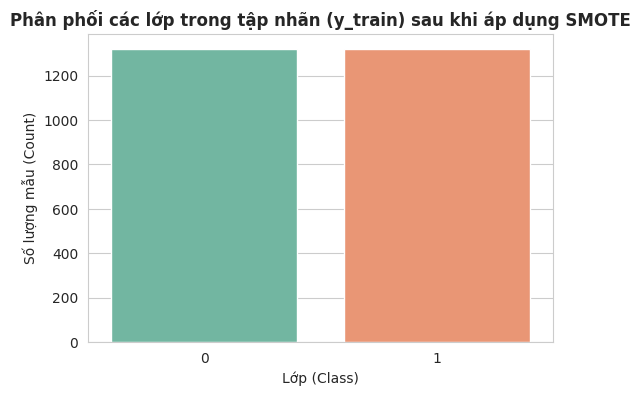

In [ ]:
print("Tỷ lệ nhãn trước khi SMOTE:")
print(pd.Series(y_train).value_counts())

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("\nTỷ lệ nhãn sau khi SMOTE:")
print(pd.Series(y_train).value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train, palette='Set2')

plt.title('Phân phối các lớp trong tập nhãn (y_train) sau khi áp dụng SMOTE', fontsize=12, fontweight='bold')
plt.xlabel('Lớp (Class)', fontsize=10)
plt.ylabel('Số lượng mẫu (Count)', fontsize=10)

plt.show()

In [ ]:
selector = SelectFromModel(
    RandomForestClassifier(random_state=42)
)

selector.fit(X_train, y_train)

X_train = selector.transform(X_train)
X_test = selector.transform(X_test)

print(f"Số lượng đặc trưng sau khi lọc: {X_train.shape[1]}")

Số lượng đặc trưng sau khi lọc: 3


In [ ]:
support_mask = selector.get_support()

selected_features = [col for col, selected in zip(numeric_cols, support_mask) if selected]

print("Các đặc trưng được giữ lại bao gồm:")
for i, col in enumerate(selected_features, 1):
    print(f"{i}. {col}")

Các đặc trưng được giữ lại bao gồm:
1. humidity
2. cloud
3. sunshine


 1. Accuracy Score: 0.8219

 2. Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.76      0.68       108
           1       0.91      0.84      0.88       330

    accuracy                           0.82       438
   macro avg       0.76      0.80      0.78       438
weighted avg       0.84      0.82      0.83       438

 3. Confusion Matrix:


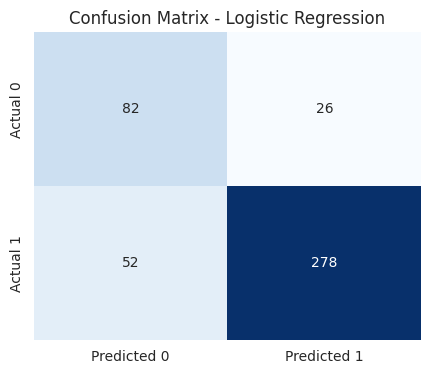


 4. ROC Curve & AUC:


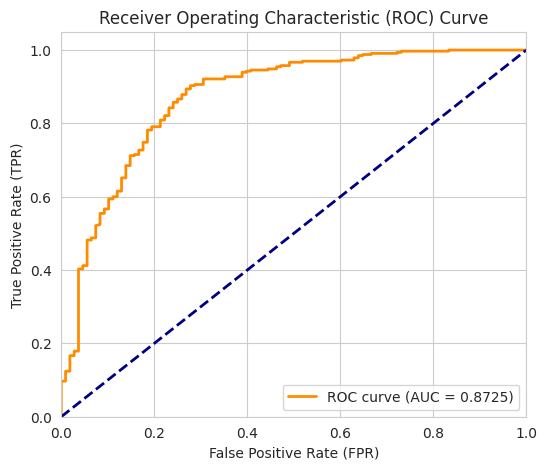

In [ ]:
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)
y_pred_prob = model_lr.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print(f" 1. Accuracy Score: {accuracy:.4f}\n")

print(" 2. Classification Report:")
print(classification_report(y_test, y_pred))

print(" 3. Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Logistic Regression')
plt.show()
print("\n 4. ROC Curve & AUC:")
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

 1. Accuracy Score: 0.8265

 Extra: Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.68      0.66       108
           1       0.89      0.88      0.88       330

    accuracy                           0.83       438
   macro avg       0.77      0.78      0.77       438
weighted avg       0.83      0.83      0.83       438

 2. ROC Curve & AUC:


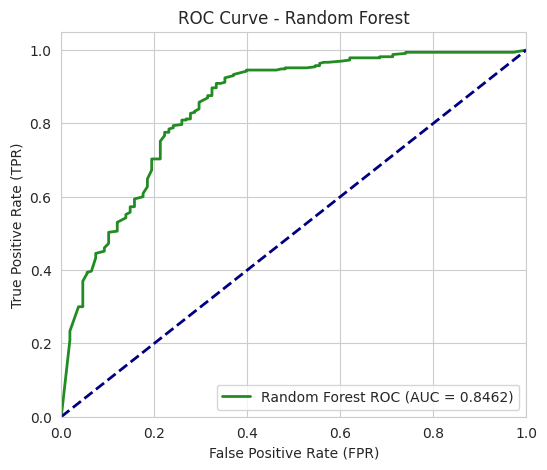


 3. Confusion Matrix:


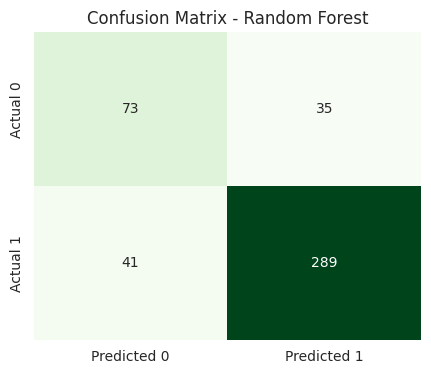

In [ ]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
y_pred_prob_rf = model_rf.predict_proba(X_test)[:, 1]
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f" 1. Accuracy Score: {accuracy_rf:.4f}\n")
print(" Extra: Classification Report:")
print(classification_report(y_test, y_pred_rf))
print(" 2. ROC Curve & AUC:")
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_prob_rf)
auc_score_rf = roc_auc_score(y_test, y_pred_prob_rf)
plt.figure(figsize=(6, 5))
plt.plot(fpr_rf, tpr_rf, color='forestgreen', lw=2, label=f'Random Forest ROC (AUC = {auc_score_rf:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.show()
print("\n 3. Confusion Matrix:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Random Forest')
plt.show()

 1. Accuracy Score: 0.8288

 Extra: Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.65      0.65       108
           1       0.89      0.89      0.89       330

    accuracy                           0.83       438
   macro avg       0.77      0.77      0.77       438
weighted avg       0.83      0.83      0.83       438

 2. ROC Curve & AUC:


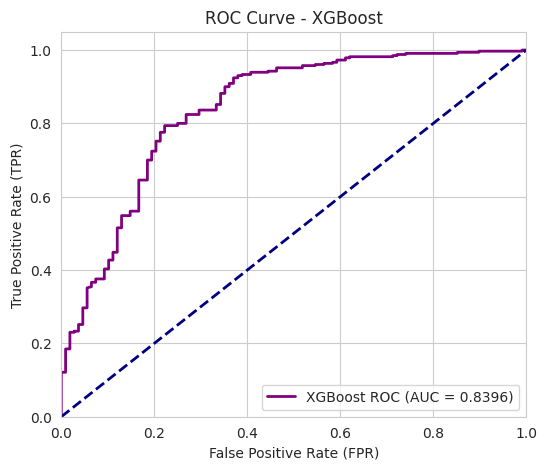


 3. Confusion Matrix:


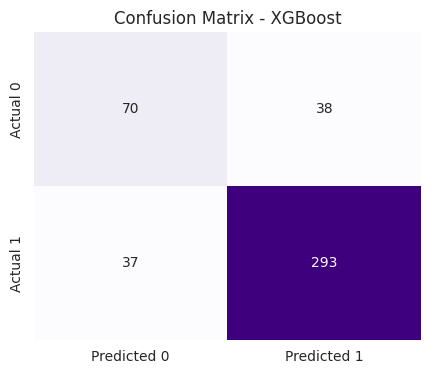

In [ ]:
model_xgb = XGBClassifier(random_state=42, eval_metric='logloss')
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)
y_pred_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f" 1. Accuracy Score: {accuracy_xgb:.4f}\n")
print(" Extra: Classification Report:")
print(classification_report(y_test, y_pred_xgb))
print(" 2. ROC Curve & AUC:")
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_prob_xgb)
auc_score_xgb = roc_auc_score(y_test, y_pred_prob_xgb)
plt.figure(figsize=(6, 5))
plt.plot(fpr_xgb, tpr_xgb, color='purple', lw=2, label=f'XGBoost ROC (AUC = {auc_score_xgb:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve - XGBoost')
plt.legend(loc="lower right")
plt.show()
print("\n 3. Confusion Matrix:")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - XGBoost')
plt.show()

In [ ]:
print("Tối ưu Hyperparameter cho Random Forest")
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(X_train, y_train)

best_rf_model = grid_rf.best_estimator_
print(f"Bộ tham số Random Forest tốt nhất: {grid_rf.best_params_}")
print("\nTối ưu Hyperparameter cho XGBoost")

xgb_param_grid = {
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 6, 9],
    'subsample': [0.8, 1.0],
    'n_estimators': [100, 200]
}

grid_xgb = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=xgb_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_xgb.fit(X_train, y_train)

best_xgb_model = grid_xgb.best_estimator_
print(f"Bộ tham số XGBoost tốt nhất: {grid_xgb.best_params_}")

Tối ưu Hyperparameter cho Random Forest
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Bộ tham số Random Forest tốt nhất: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Tối ưu Hyperparameter cho XGBoost
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Bộ tham số XGBoost tốt nhất: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
best_model = best_xgb_model
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_metrics = ['accuracy', 'f1', 'roc_auc']
cv_results = cross_validate(
    estimator=best_model,
    X=X_train,
    y=y_train,
    cv=skf,
    scoring=scoring_metrics,
    n_jobs=-1
)

print("="*40)
print(" KẾT QUẢ 5-FOLD CROSS VALIDATION TRUNG BÌNH:")
print("="*40)
print(f"• Accuracy trung bình: {cv_results['test_accuracy'].mean():.4f}")
print(f"• F1-Score trung bình: {cv_results['test_f1'].mean():.4f}")
print(f"• ROC AUC trung bình:  {cv_results['test_roc_auc'].mean():.4f}")
print("="*40)

 KẾT QUẢ 5-FOLD CROSS VALIDATION TRUNG BÌNH:
• Accuracy trung bình: 0.8636
• F1-Score trung bình: 0.8674
• ROC AUC trung bình:  0.9290


In [ ]:
def get_metrics(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else [0]*len(y_test)

    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'ROC AUC': roc_auc_score(y_test, y_prob) if hasattr(model, "predict_proba") else 0
    }
df_compare = pd.DataFrame({
    'Logistic': get_metrics(model_lr, X_test, y_test),
    'Random Forest': get_metrics(best_rf_model, X_test, y_test),
    'XGBoost': get_metrics(best_xgb_model, X_test, y_test)
}).T
print("BẢNG SO SÁNH CÁC MÔ HÌNH CHÍNH THỨC:")
display(df_compare.round(4))

BẢNG SO SÁNH CÁC MÔ HÌNH CHÍNH THỨC:


,Accuracy,Precision,Recall,F1,ROC AUC
Logistic,0.8219,0.9145,0.8424,0.8770,0.8725
Random Forest,0.8288,0.8947,0.8758,0.8851,0.8510
XGBoost,0.8425,0.9015,0.8879,0.8947,0.8630


In [ ]:
from sklearn.linear_model import Ri